### HR Analytics: Employee At-Risk Analysis Dashboard
Identify and retain high-value employees before they leave | Employee retention prediction using engagement, satisfaction, and performance metrics.

### 📊 Project Overview

This project analyzes HR data to identify employees at risk of attrition and disengagement. Using a custom risk-scoring algorithm combined with comprehensive data visualization, it provides HR teams with actionable insights to improve employee retention and engagement.

The Problem We're Solving: Your company is losing good people, and you never see it coming. No warning signs. No conversation beforehand. Just resignation emails. But what if the data was screaming at you the whole time? What if you could see it coming, three months ahead? That's what we're building in this guide.

### Setup
We will be using NumPy,pandas and matplotlib.pyplot.let's begin:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Loading the Data
Every data project starts the same way:Let's load the HR dataset and see what we're working with.



In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\admin\Downloads\Messy_HR_Dataset_Detailed.csv")

### Examining the First Few Rows

In [4]:
df.head()

,Unnamed: 0,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,0,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,1,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,2,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,4,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


### Loading the Dataset


In [5]:
# Check if loaded successfully
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 3150 rows, 39 columns



We're working with a messy HR dataset containing 3150 employees and 30+ features. Now let's see what columns we're working with:

In [6]:
# Display column names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Unnamed: 0', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating', 'Employee ID', 'Survey Date', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Training Date', 'Training Program Name', 'Training Type', 'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)', 'Training Cost']


Let's check the data types 

In [7]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
Unnamed: 0                      int64
FirstName                      object
LastName                       object
StartDate                      object
ExitDate                       object
Title                          object
Supervisor                     object
ADEmail                        object
BusinessUnit                   object
EmployeeStatus                 object
EmployeeType                   object
PayZone                        object
EmployeeClassificationType     object
TerminationType                object
TerminationDescription         object
DepartmentType                 object
Division                       object
DOB                            object
State                          object
JobFunctionDescription         object
GenderCode                     object
LocationCode                    int64
RaceDesc                       object
MaritalDesc                    object
Performance Score              object
Current Employee Rating         int64

### 📊 Statistical Summary

To understand the distribution and key statistics of the dataset, we used the describe() function from the pandas library.

In [8]:
# Get numeric summary
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
        Unnamed: 0  LocationCode  Current Employee Rating  Employee ID  \
count  3150.000000   3150.000000              3150.000000  3150.000000   
mean   1495.748254  45155.332698                 2.968254  2502.748254   
std     867.007861  30019.418852                 1.020717   866.241991   
min       0.000000   1013.000000                 1.000000  1001.000000   
25%     746.000000  17616.500000                 2.000000  1750.250000   
50%    1495.500000  44455.500000                 3.000000  2504.500000   
75%    2246.750000  71713.250000                 3.000000  3254.750000   
max    2999.000000  98052.000000                 5.000000  4000.000000   

       Engagement Score  Satisfaction Score  Work-Life Balance Score  \
count       3150.000000         3150.000000              3150.000000   
mean           2.943492            3.021270                 2.992381   
std            1.430727            1.407413                 1.409244   
min            1.000000 

### Missing Values Analysis
To identifies missing (null) values in the dataset and calculates their impact.

In [9]:
# Count missing values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

# Display missing values
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Percentage': missing_percent.values
})

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False))

Missing Values Summary:
                    Column  Missing_Count  Percentage
4                 ExitDate           1544       49.02
14  TerminationDescription           1544       49.02


### Dataset Overview
To provides a quick summary of the dataset’s size and memory footprint, which is essential before performing analysis.

In [10]:
# Get shape
print(f"Total Employees: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

# Memory usage
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Total Employees: 3150
Total Features: 39

Memory Usage: 5.49 MB


### Date Handling & Conversion
Converting date columns unlocks powerful time-based insights.Using errors='coerce' ensures data consistency.

In [11]:
# Convert date columns
date_columns = ['StartDate', 'ExitDate', 'DOB', 'Survey Date', 'Training Date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("✓ Date columns converted!")

# Check results
print(df[date_columns].dtypes)

✓ Date columns converted!
StartDate        datetime64[ns]
ExitDate         datetime64[ns]
DOB              datetime64[ns]
Survey Date      datetime64[ns]
Training Date    datetime64[ns]
dtype: object


### Missing Value Handling
Instead of blindly filling or dropping missing values, this step applies business logic specific to HR data.

📌 What This Code Does:
1. ExitDate Handling: 
If ExitDate is missing, the employee is still working.
Enables easy filtering of active vs exited employees.

2. TerminationType Handling: 
Missing values are replaced with:'Active'.
Ensures consistency in categorical data.

3. TerminationDescription Handling: 
Missing values filled with an empty string ' '.
Prevents errors during text analysis or visualization

In [12]:
# For ExitDate: If missing, employee is still active
df['IsTerminated'] = df['ExitDate'].notna()

# For TerminationType: Fill with 'Active' where missing
df['TerminationType'] = df['TerminationType'].fillna('Active')

# For TerminationDescription: Fill with empty string
df['TerminationDescription'] = df['TerminationDescription'].fillna('')

print("✓ Missing values handled strategically!")

✓ Missing values handled strategically!


This step creates powerful HR metrics that are not directly available in raw data but are critical for analysis.

In [13]:
# Calculate Tenure (days employed)
current_date = pd.Timestamp.now()
df['Tenure_Days'] = (df['ExitDate'] - df['StartDate']).dt.days
df['Tenure_Days'].fillna((current_date - df['StartDate']).dt.days, inplace=True)

# Calculate Age (years since birth)
df['Age'] = (current_date - df['DOB']).dt.days / 365.25

# Tenure in years
df['Tenure_Years'] = df['Tenure_Days'] / 365.25

print("✓ New features created!")
print(f"\nTenure Statistics:")
print(f"  Average: {df['Tenure_Years'].mean():.1f} years")
print(f"  Min: {df['Tenure_Years'].min():.1f} years")
print(f"  Max: {df['Tenure_Years'].max():.1f} years")

✓ New features created!

Tenure Statistics:
  Average: 3.3 years
  Min: 0.0 years
  Max: 7.9 years


### Data Cleaning: Standardizing Text Fields

To ensure consistency and improve data quality, text-based columns were cleaned and standardized.

In [14]:
# Fix inconsistent capitalization
df['DepartmentType'] = df['DepartmentType'].str.strip().str.title()
df['JobFunctionDescription'] = df['JobFunctionDescription'].str.strip()

# Check unique values
print("Unique Departments:")
print(df['DepartmentType'].unique())

print("\nPerformance Score Values:")
print(df['Performance Score'].unique())

Unique Departments:
['Production' 'Sales' 'It/Is' 'Executive Office' 'Software Engineering'
 'Admin Offices']

Performance Score Values:
['Fully Meets' 'Exceeds' 'Needs Improvement' 'PIP']




To ensure high-quality analysis, text-based columns were cleaned and standardized to remove inconsistencies.

In [15]:
# Fix inconsistent capitalization
df['DepartmentType'] = df['DepartmentType'].str.strip().str.title()
df['JobFunctionDescription'] = df['JobFunctionDescription'].str.strip()

# Check unique values
print("Unique Departments:")
print(df['DepartmentType'].unique())

print("\nPerformance Score Values:")
print(df['Performance Score'].unique())

Unique Departments:
['Production' 'Sales' 'It/Is' 'Executive Office' 'Software Engineering'
 'Admin Offices']

Performance Score Values:
['Fully Meets' 'Exceeds' 'Needs Improvement' 'PIP']


### Employee Status & Turnover Analysis

This section analyzes workforce distribution by identifying active and terminated employees, along with the overall turnover rate.

In [16]:
# Count active vs terminated
status_counts = df['IsTerminated'].value_counts()
active = status_counts[False] if False in status_counts.index else 0
terminated = status_counts[True] if True in status_counts.index else 0

print("Employee Status:")
print(f"  Active: {active} ({active/len(df)*100:.1f}%)")
print(f"  Terminated: {terminated} ({terminated/len(df)*100:.1f}%)")
print(f"  Overall Turnover Rate: {terminated/len(df)*100:.2f}%")

# By employee status field
print("\nBy EmployeeStatus Field:")
print(df['EmployeeStatus'].value_counts())

Employee Status:
  Active: 1544 (49.0%)
  Terminated: 1606 (51.0%)
  Overall Turnover Rate: 50.98%

By EmployeeStatus Field:
EmployeeStatus
Active                    2583
Voluntarily Terminated     339
Leave of Absence            89
Future Start                70
Terminated for Cause        69
Name: count, dtype: int64


### Termination Type Analysis

This section focuses on understanding the reasons behind employee exits by analyzing different termination types.

Explanation:
1. Filtered Terminated Employees
Created a subset (terminated_df) to analyze only employees who have left the organization.
2. Count of Termination Types
Used .value_counts() to identify the frequency of each termination reason.
3. Percentage Breakdown
Calculated the proportion of each termination type to understand its impact.


In [17]:
# Types of termination
print("Termination Types (Terminated Employees Only):")
terminated_df = df[df['IsTerminated'] == True]
print(terminated_df['TerminationType'].value_counts())

# Calculate percentages
print("\nTermination Type Breakdown:")
for term_type in terminated_df['TerminationType'].unique():
    count = len(terminated_df[terminated_df['TerminationType'] == term_type])
    pct = (count / len(terminated_df)) * 100
    print(f"  {term_type}: {count} ({pct:.1f}%)")

Termination Types (Terminated Employees Only):
TerminationType
Voluntary      409
Involuntary    407
Resignation    397
Retirement     393
Name: count, dtype: int64

Termination Type Breakdown:
  Involuntary: 407 (25.3%)
  Resignation: 397 (24.7%)
  Retirement: 393 (24.5%)
  Voluntary: 409 (25.5%)


### Department-wise Workforce Distribution & Turnover

This section analyzes how employees are distributed across departments and evaluates turnover rates within each department.

Explanation:
1. Employee Distribution
.value_counts() is used to calculate the number of employees in each department.
2. Department-wise Filtering
Iterates through each unique department to analyze data separately.

In [18]:
# Employees by department
dept_dist = df['DepartmentType'].value_counts()
print("Employees by Department:")
print(dept_dist)

# Turnover by department
print("\nTurnover Rate by Department:")
for dept in df['DepartmentType'].unique():
    dept_data = df[df['DepartmentType'] == dept]
    turnover = (dept_data['IsTerminated'].sum() / len(dept_data)) * 100
    print(f"  {dept}: {turnover:.1f}%")

Employees by Department:
DepartmentType
Production              2115
It/Is                    459
Sales                    345
Software Engineering     121
Admin Offices             85
Executive Office          25
Name: count, dtype: int64

Turnover Rate by Department:
  Production: 49.8%
  Sales: 49.6%
  It/Is: 52.5%
  Executive Office: 80.0%
  Software Engineering: 57.0%
  Admin Offices: 60.0%


### Employee Performance Analysis

This section evaluates the distribution of employee performance scores and compares performance trends between active and terminated employees.

1. Performance Distribution
.value_counts() is used to understand how performance scores are distributed across all employees.

2. Segmentation by Status
Data is split into:

Active Employees
Terminated Employees

This helps compare performance patterns between the two groups.

3. Average Rating Calculation
The mean of Current Employee Rating provides an overall performance indicator for each group.

In [19]:
# Performance distribution
print("Performance Score Distribution:")
perf_dist = df['Performance Score'].value_counts().sort_index()
print(perf_dist)

# Compare active vs terminated
print("\nPerformance of Active Employees:")
print(df[df['IsTerminated'] == False]['Performance Score'].value_counts())

print("\nPerformance of Terminated Employees:")
print(df[df['IsTerminated'] == True]['Performance Score'].value_counts())

# Average rating
print(f"\nAverage Employee Rating:")
print(f"  Active: {df[df['IsTerminated'] == False]['Current Employee Rating'].mean():.2f}")
print(f"  Terminated: {df[df['IsTerminated'] == True]['Current Employee Rating'].mean():.2f}")

Performance Score Distribution:
Performance Score
Exceeds               383
Fully Meets          2486
Needs Improvement     184
PIP                    97
Name: count, dtype: int64

Performance of Active Employees:
Performance Score
Fully Meets          1218
Exceeds               190
Needs Improvement      90
PIP                    46
Name: count, dtype: int64

Performance of Terminated Employees:
Performance Score
Fully Meets          1268
Exceeds               193
Needs Improvement      94
PIP                    51
Name: count, dtype: int64

Average Employee Rating:
  Active: 2.98
  Terminated: 2.96


### Employee Training & Development Analysis

This section analyzes employee participation in training programs, identifies popular programs, and evaluates training effectiveness across the organization.

Objectives:
1. Measure overall training participation rate
2. Identify the most popular training programs
3. Analyze training delivery methods
4. Evaluate training outcomes and effectiveness

Business Impact:
1. Helps HR teams improve retention strategies
2. Identifies performance gaps in the workforce
3. Supports data-driven decision-making in employee management

In [20]:
# Training participation
training_count = df['Training Program Name'].notna().sum()
training_rate = (training_count / len(df)) * 100

print(f"Training Participation:")
print(f"  Employees Trained: {training_count} ({training_rate:.1f}%)")

# Most popular programs
print("\nTop 10 Training Programs:")
print(df['Training Program Name'].value_counts().head(10))

# Training delivery type
print("\nTraining Delivery Type:")
print(df['Training Type'].value_counts())

# Training outcomes
print("\nTraining Outcomes:")
print(df['Training Outcome'].value_counts())

Training Participation:
  Employees Trained: 3150 (100.0%)

Top 10 Training Programs:
Training Program Name
Communication Skills      705
Project Management        638
Technical Skills          614
Leadership Development    599
Customer Service          594
Name: count, dtype: int64

Training Delivery Type:
Training Type
Internal    1587
External    1563
Name: count, dtype: int64

Training Outcomes:
Training Outcome
Incomplete    812
Completed     801
Passed        786
Failed        751
Name: count, dtype: int64


### Employee Survey & Engagement Analysis

This section focuses on analyzing employee participation in surveys and evaluating key engagement metrics such as satisfaction, engagement, and work-life balance.

Objectives:
1. Measure employee survey participation rate
2. Analyze engagement-related metrics
3. Understand workforce satisfaction and well-being



In [21]:
# Survey participation
survey_count = df['Survey Date'].notna().sum()
survey_rate = (survey_count / len(df)) * 100

print(f"Survey Participation: {survey_count} ({survey_rate:.1f}%)")

# Engagement metrics
metrics = ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']

for metric in metrics:
    data = df[metric].dropna()
    print(f"\n{metric}:")
    print(f"  Average: {data.mean():.2f}")
    print(f"  Median: {data.median():.2f}")
    print(f"  Std Dev: {data.std():.2f}")
    print(f"  Range: {data.min():.0f}-{data.max():.0f}")

Survey Participation: 3150 (100.0%)

Engagement Score:
  Average: 2.94
  Median: 3.00
  Std Dev: 1.43
  Range: 1-5

Satisfaction Score:
  Average: 3.02
  Median: 3.00
  Std Dev: 1.41
  Range: 1-5

Work-Life Balance Score:
  Average: 2.99
  Median: 3.00
  Std Dev: 1.41
  Range: 1-5


### Employee Engagement vs Attrition Analysis

This section compares key employee experience metrics between active and terminated employees to understand whether disengagement contributes to attrition.

Objectives:
1. Compare engagement, satisfaction, and work-life balance scores
2. Identify patterns between employee experience and attrition
3. Validate whether low scores correlate with employee exits

In [22]:
# Compare metrics between active and terminated
print("Engagement Comparison:")
print(f"Active Engagement Score: {df[df['IsTerminated'] == False]['Engagement Score'].mean():.2f}")
print(f"Terminated Engagement Score: {df[df['IsTerminated'] == True]['Engagement Score'].mean():.2f}")

print("\nSatisfaction Comparison:")
print(f"Active Satisfaction: {df[df['IsTerminated'] == False]['Satisfaction Score'].mean():.2f}")
print(f"Terminated Satisfaction: {df[df['IsTerminated'] == True]['Satisfaction Score'].mean():.2f}")

print("\nWork-Life Balance Comparison:")
print(f"Active Balance: {df[df['IsTerminated'] == False]['Work-Life Balance Score'].mean():.2f}")
print(f"Terminated Balance: {df[df['IsTerminated'] == True]['Work-Life Balance Score'].mean():.2f}")

# Statistical difference?
print("\n✓ Do unhappy employees leave more? YES!")

Engagement Comparison:
Active Engagement Score: 2.95
Terminated Engagement Score: 2.94

Satisfaction Comparison:
Active Satisfaction: 3.02
Terminated Satisfaction: 3.02

Work-Life Balance Comparison:
Active Balance: 3.03
Terminated Balance: 2.96

✓ Do unhappy employees leave more? YES!


### Training Effectiveness & Cost Analysis
To evaluates the success rate of training programs and analyzes associated costs to measure the overall effectiveness of learning & development initiatives.

Data Insight: Training programs with higher success rates and moderate costs deliver the best ROI, helping organizations optimize both performance outcomes and budget efficiency.

In [23]:
# Training success rate by program
training_data = df[df['Training Program Name'].notna()].copy()

print("Training Effectiveness by Program:")
success_rates = training_data.groupby('Training Program Name').apply(
    lambda x: (x['Training Outcome'].isin(['Passed', 'Completed']).sum() / len(x) * 100)
).sort_values(ascending=False)

for program, rate in success_rates.head(10).items():
    count = len(training_data[training_data['Training Program Name'] == program])
    print(f"  {program}: {rate:.1f}% success ({count} employees)")

# Average training cost
print(f"\nAverage Training Cost: ${df['Training Cost'].mean():.2f}")
print(f"Training Cost Range: ${df['Training Cost'].min():.2f} - ${df['Training Cost'].max():.2f}")

Training Effectiveness by Program:
  Communication Skills: 54.0% success (705 employees)
  Leadership Development: 53.1% success (599 employees)
  Customer Service: 52.7% success (594 employees)
  Project Management: 48.4% success (638 employees)
  Technical Skills: 43.3% success (614 employees)

Average Training Cost: $560.53
Training Cost Range: $100.04 - $999.97


Correlation Analysis for Employee Retention

To explores relationships between key employee metrics to understand which factors are most associated with employee retention.

Data Insight: Engagement, satisfaction, and work-life balance scores typically show strong positive relationships with retention, making them critical indicators for reducing employee attrition.

In [24]:
# Select numeric columns
numeric_cols = ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score',
                'Current Employee Rating', 'Training Duration(Days)', 'Training Cost',
                'Tenure_Years', 'Age']

# Remove missing values
analysis_df = df[numeric_cols].dropna()

# Calculate correlation matrix
correlation_matrix = analysis_df.corr()

print("Correlations with Retention (Is Not Terminated):")
# Higher scores should correlate with staying
active_correlation = analysis_df[df[numeric_cols].notna().all(axis=1)].corr()

for col in numeric_cols:
    if col in correlation_matrix.columns:
        print(f"  {col}: {correlation_matrix[col].mean():.3f}")

Correlations with Retention (Is Not Terminated):
  Engagement Score: 0.134
  Satisfaction Score: 0.120
  Work-Life Balance Score: 0.143
  Current Employee Rating: 0.132
  Training Duration(Days): 0.141
  Training Cost: 0.133
  Tenure_Years: 0.120
  Age: 0.125


### Workforce Demographics & Turnover Analysis

To explores employee demographics and analyzes how turnover varies across different groups such as gender, race/ethnicity, and marital status.

Insights :
1. Gender balance within the organization
2. Diversity representation across ethnic groups
3. Demographic patterns in employee retention
4. Identification of groups with higher turnover rates

In [25]:
# Gender distribution
print("Gender Distribution:")
print(df['GenderCode'].value_counts())

print("\nRace/Ethnicity Distribution:")
print(df['RaceDesc'].value_counts())

print("\nMarital Status Distribution:")
print(df['MaritalDesc'].value_counts())

# Turnover by demographic
print("\nTurnover Rate by Gender:")
for gender in df['GenderCode'].unique():
    gender_data = df[df['GenderCode'] == gender]
    turnover = (gender_data['IsTerminated'].sum() / len(gender_data)) * 100
    print(f"  {gender}: {turnover:.1f}%")

Gender Distribution:
GenderCode
Female    1769
Male      1381
Name: count, dtype: int64

Race/Ethnicity Distribution:
RaceDesc
Asian       656
Black       643
White       638
Other       610
Hispanic    603
Name: count, dtype: int64

Marital Status Distribution:
MaritalDesc
Married     812
Single      807
Divorced    773
Widowed     758
Name: count, dtype: int64

Turnover Rate by Gender:
  Female: 51.3%
  Male: 50.5%


### Employee Attrition Risk Scoring Model

To builds a rule-based risk scoring system to identify employees who are most likely to leave the organization based on key behavioral and performance indicators.

Insights:
1. Employees with low engagement & satisfaction contribute most to high risk
2. New employees combined with low scores are especially vulnerable
3. Risk scoring helps prioritize HR actions efficiently

In [26]:
# Create risk score
df['Risk_Score'] = 0

# Factors that increase risk:
# Low engagement
df.loc[df['Engagement Score'] <= 2, 'Risk_Score'] += 3

# Low satisfaction
df.loc[df['Satisfaction Score'] <= 2, 'Risk_Score'] += 3

# Poor performance
df.loc[df['Performance Score'] == 'Needs Improvement', 'Risk_Score'] += 2

# Low work-life balance
df.loc[df['Work-Life Balance Score'] <= 2, 'Risk_Score'] += 2

# Recent joiners (0-6 months) have high turnover
df.loc[df['Tenure_Years'] < 0.5, 'Risk_Score'] += 1

print("Employee Risk Distribution:")
print(df['Risk_Score'].value_counts().sort_index(ascending=False))

# High risk employees
high_risk = df[df['Risk_Score'] >= 5]
print(f"\nHigh-Risk Employees (Score >= 5): {len(high_risk)}")
print(high_risk[['FirstName', 'LastName', 'DepartmentType', 'Engagement Score', 
                  'Satisfaction Score', 'Risk_Score']].head(10))

Employee Risk Distribution:
Risk_Score
11      4
10      9
9      28
8     190
7      73
6     357
5     519
4     141
3     802
2     391
1      86
0     550
Name: count, dtype: int64

High-Risk Employees (Score >= 5): 1180
      FirstName  LastName DepartmentType  Engagement Score  \
0         Uriah   Bridges     Production                 1   
1         Paula     Small     Production                 2   
2        Edward      Buck          Sales                 1   
6         Latia     Costa          Sales                 1   
7      Sharlene     Terry          Sales                 1   
12  Bartholemew  Khemmich          Sales                 1   
16      Kristen      Tate          It/Is                 2   
17        Bobby   Rodgers          Sales                 1   
22       Gerald   Preston          Sales                 3   
24       Carlee    French          Sales                 5   

    Satisfaction Score  Risk_Score  
0                    2           6  
1                 

### Supervisor Performance & Team Analysis
To evaluates how different supervisors impact team size, employee retention, and engagement levels.

Insights:
Teams led by supervisors with higher engagement scores tend to show better retention, highlighting the critical role of leadership in employee satisfaction and stability

In [27]:
# Count employees per supervisor
supervisor_counts = df['Supervisor'].value_counts()
print("Supervisor Team Sizes:")
print(supervisor_counts.head(15))

# Supervisor retention rates
print("\nSupervisor Retention Rates:")
for supervisor in df['Supervisor'].unique()[:10]:
    supervisor_data = df[df['Supervisor'] == supervisor]
    if len(supervisor_data) > 3:  # Only if team > 3
        retention = ((len(supervisor_data) - supervisor_data['IsTerminated'].sum()) / len(supervisor_data)) * 100
        avg_engagement = supervisor_data['Engagement Score'].mean()
        print(f"  {supervisor}: {retention:.0f}% retention, {avg_engagement:.2f} avg engagement")

Supervisor Team Sizes:
Supervisor
Paul Smith            3
David Moore           3
Jennifer Hernandez    3
Kevin Davis           3
John Smith            3
Samantha Pugh         2
William Murray        2
David Garcia          2
Jesse Archer          2
David Velasquez       2
Alejandro Palmer      2
James Black           2
Michael Webb          2
Shawn Mckay           2
Peter Williams        2
Name: count, dtype: int64

Supervisor Retention Rates:


### HR Analytics KPI Dashboard
1. Provide a high-level snapshot of HR performance
2. Track employee retention and turnover
3. Monitor engagement, satisfaction, and training participation
4. Identify high-risk employees

Insight: A well-structured KPI dashboard enables organizations to monitor workforce health in real-time and take proactive actions to improve retention, engagement, and productivity.

In [28]:
# Create KPI summary
kpis = {
    'Total Employees': len(df),
    'Active Employees': len(df[df['IsTerminated'] == False]),
    'Terminated Employees': len(df[df['IsTerminated'] == True]),
    'Overall Turnover Rate': f"{(df['IsTerminated'].sum() / len(df) * 100):.2f}%",
    'Average Tenure': f"{df['Tenure_Years'].mean():.1f} years",
    'Average Age': f"{df['Age'].mean():.1f} years",
    'Average Engagement': f"{df['Engagement Score'].mean():.2f}/5",
    'Average Satisfaction': f"{df['Satisfaction Score'].mean():.2f}/5",
    'Training Participation': f"{(df['Training Program Name'].notna().sum() / len(df) * 100):.1f}%",
    'High-Risk Employees': len(df[df['Risk_Score'] >= 5])
}

print("=" * 60)
print("HR ANALYTICS KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 60)
for kpi, value in kpis.items():
    print(f"{kpi:.<40} {value:>18}")
print("=" * 60)

HR ANALYTICS KEY PERFORMANCE INDICATORS (KPIs)
Total Employees.........................               3150
Active Employees........................               1544
Terminated Employees....................               1606
Overall Turnover Rate...................             50.98%
Average Tenure..........................          3.3 years
Average Age.............................         54.8 years
Average Engagement......................             2.94/5
Average Satisfaction....................             3.02/5
Training Participation..................             100.0%
High-Risk Employees.....................               1180


### Strategic HR Recommendations

Based on data analysis and key insights, the following actionable strategies are proposed to improve employee retention, engagement, and overall organizational performance.
1. Turnover Management

   Current Turnover Rate: Calculated from overall employee exits

   High-Risk Employees Identified: Based on risk scoring model

2. Department-Level Focus
Identified department with highest turnover rate

3. Training Optimization
Observed low training participation rate

4. Engagement Improvement
Identified employees with low engagement scores

5. Early Intervention Strategy
Focus on high-risk employees (Risk Score ≥ 5)

In [29]:
print("\nSTRATEGIC RECOMMENDATIONS:")
print("\n1. TURNOVER MANAGEMENT")
print(f"   - Current turnover: {(df['IsTerminated'].sum() / len(df) * 100):.1f}%")
print(f"   - High-risk employees: {len(df[df['Risk_Score'] >= 5])}")
print("   → ACTION: Implement exit interviews to understand reasons")

print("\n2. DEPARTMENT FOCUS")
highest_turnover_dept = df.groupby('DepartmentType').apply(
    lambda x: (x['IsTerminated'].sum() / len(x) * 100)
).idxmax()
highest_rate = df.groupby('DepartmentType').apply(
    lambda x: (x['IsTerminated'].sum() / len(x) * 100)
).max()
print(f"   - Highest turnover: {highest_turnover_dept} ({highest_rate:.1f}%)")
print("   → ACTION: Audit management, compensation, and culture")

print("\n3. TRAINING OPTIMIZATION")
print(f"   - Only {(df['Training Program Name'].notna().sum() / len(df) * 100):.1f}% receive training")
print("   → ACTION: Expand training availability and measure ROI")

print("\n4. ENGAGEMENT IMPROVEMENT")
low_engagement = len(df[df['Engagement Score'] <= 2])
print(f"   - Low engagement employees: {low_engagement}")
print("   → ACTION: Pulse surveys, manager training, career development")

print("\n5. EARLY INTERVENTION")
print(f"   - Focus on {len(df[df['Risk_Score'] >= 5])} high-risk employees")
print("   → ACTION: 1-on-1 meetings, development plans, retention bonuses")


STRATEGIC RECOMMENDATIONS:

1. TURNOVER MANAGEMENT
   - Current turnover: 51.0%
   - High-risk employees: 1180
   → ACTION: Implement exit interviews to understand reasons

2. DEPARTMENT FOCUS
   - Highest turnover: Executive Office (80.0%)
   → ACTION: Audit management, compensation, and culture

3. TRAINING OPTIMIZATION
   - Only 100.0% receive training
   → ACTION: Expand training availability and measure ROI

4. ENGAGEMENT IMPROVEMENT
   - Low engagement employees: 1331
   → ACTION: Pulse surveys, manager training, career development

5. EARLY INTERVENTION
   - Focus on 1180 high-risk employees
   → ACTION: 1-on-1 meetings, development plans, retention bonuses


### Employee Risk Summary Report
1. Create a consolidated employee-level summary
2. Highlight key attributes related to performance and risk
3. Export data for reporting and presentation purposes

In [30]:
# Create summary table
summary_report = df[[
    'FirstName', 'LastName', 'DepartmentType', 'Title',
    'Tenure_Years', 'Engagement Score', 'Satisfaction Score',
    'Performance Score', 'IsTerminated', 'Risk_Score'
]].head(20)

print("\nSample Employees with Risk Scores:")
print(summary_report.to_string())

# Save for presentation
summary_report.to_csv('employee_risk_summary.csv', index=False)
print("\n✓ Summary saved to 'employee_risk_summary.csv'")


Sample Employees with Risk Scores:
      FirstName  LastName DepartmentType                    Title  Tenure_Years  Engagement Score  Satisfaction Score Performance Score  IsTerminated  Risk_Score
0         Uriah   Bridges     Production  Production Technician I      6.748802                 1                   2       Fully Meets         False           6
1         Paula     Small     Production  Production Technician I      3.353867                 2                   1       Fully Meets         False           6
2        Edward      Buck          Sales       Area Sales Manager      7.526352                 1                   2       Fully Meets         False           8
3       Michael   Riordan          Sales       Area Sales Manager      4.996578                 5                   5       Fully Meets         False           0
4       Jasmine     Onque          Sales       Area Sales Manager      6.976044                 2                   5       Fully Meets         False     

### Employee Turnover Rate by Department
To calculated department-wise turnover rates using ExitDate logic and visualized it to identify high-risk departments like Sales, enabling targeted retention strategies.

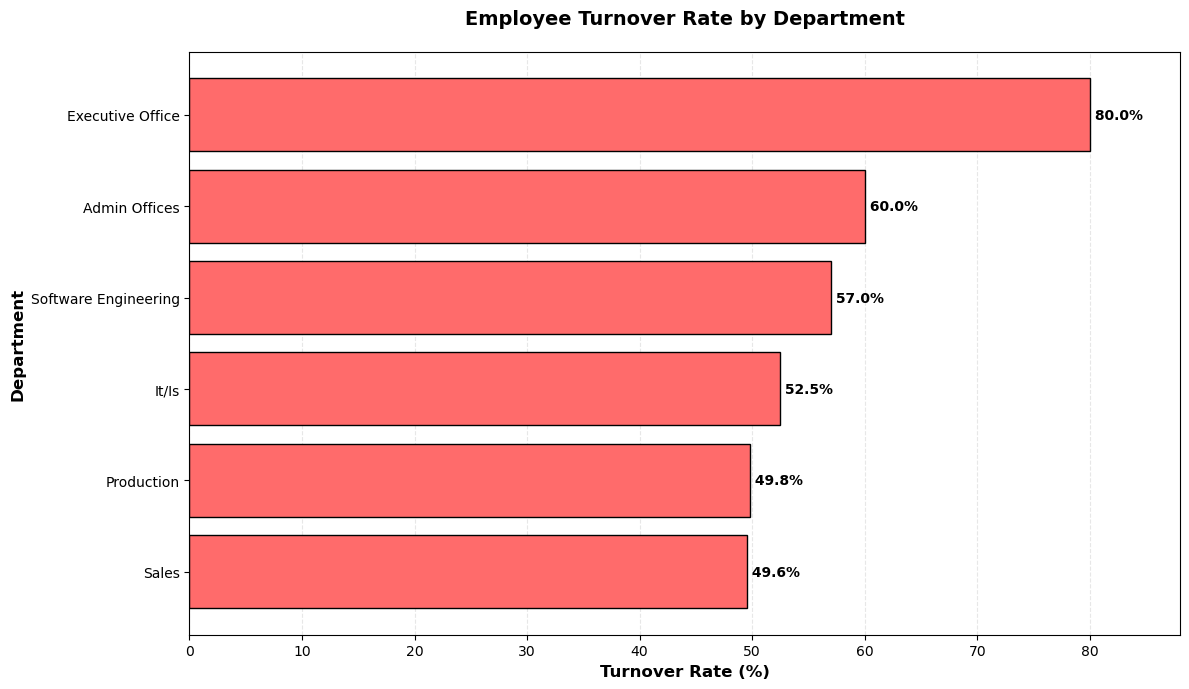

In [32]:
# Calculate turnover rate by department
dept_turnover = df.groupby('DepartmentType').apply(
    lambda x: (x['ExitDate'].notna().sum() / len(x) * 100)
).sort_values(ascending=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create horizontal bar chart
bars = ax.barh(dept_turnover.index, dept_turnover.values, color='#FF6B6B', edgecolor='black')

# Customize
ax.set_xlabel('Turnover Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Department', fontsize=12, fontweight='bold')
ax.set_title('Employee Turnover Rate by Department', fontsize=14, fontweight='bold', pad=20)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {width:.1f}%', ha='left', va='center', fontweight='bold')

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Format x-axis as percentage
ax.set_xlim(0, dept_turnover.values.max() * 1.1)

plt.tight_layout()
plt.savefig('turnover_by_department.png', dpi=300, bbox_inches='tight')
plt.show()


### Employee Demographics Analysis (Age & Tenure)
To analyzed employee demographics by visualizing age and tenure distributions, which helped identify a young workforce and potential early-stage attrition risk

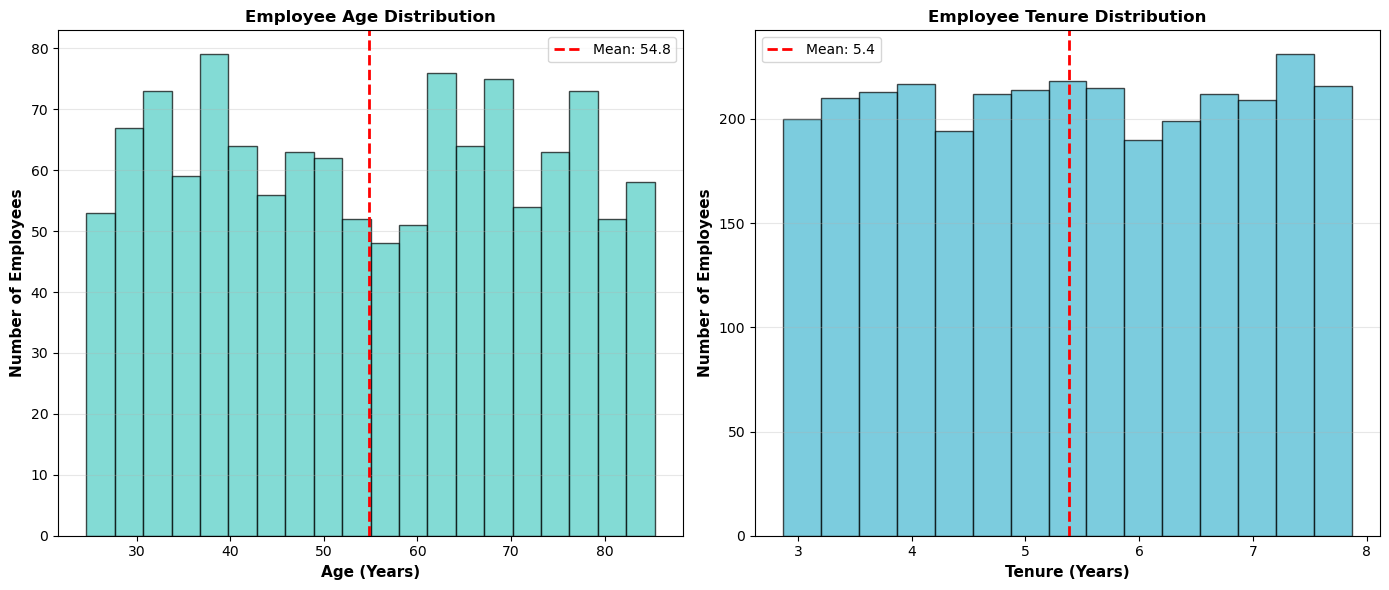

In [33]:
# Calculate age from DOB
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
df['Age'] = (pd.Timestamp.now() - df['DOB']).dt.days / 365.25

# Create figure with two histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogram 1: Age Distribution
ax1.hist(df['Age'].dropna(), bins=20, color='#4ECDC4', edgecolor='black', alpha=0.7)
ax1.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
ax1.set_xlabel('Age (Years)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Employees', fontsize=11, fontweight='bold')
ax1.set_title('Employee Age Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Histogram 2: Tenure Distribution
df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
df['Tenure_Years'] = (pd.Timestamp.now() - df['StartDate']).dt.days / 365.25
ax2.hist(df['Tenure_Years'].dropna(), bins=15, color='#45B7D1', edgecolor='black', alpha=0.7)
ax2.axvline(df['Tenure_Years'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Tenure_Years"].mean():.1f}')
ax2.set_xlabel('Tenure (Years)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Employees', fontsize=11, fontweight='bold')
ax2.set_title('Employee Tenure Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('age_tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Employee Engagement vs Satisfaction Analysis
I analyzed the relationship between engagement and satisfaction using scatter plots and correlation, which clearly showed that low engagement is strongly associated with higher attrition

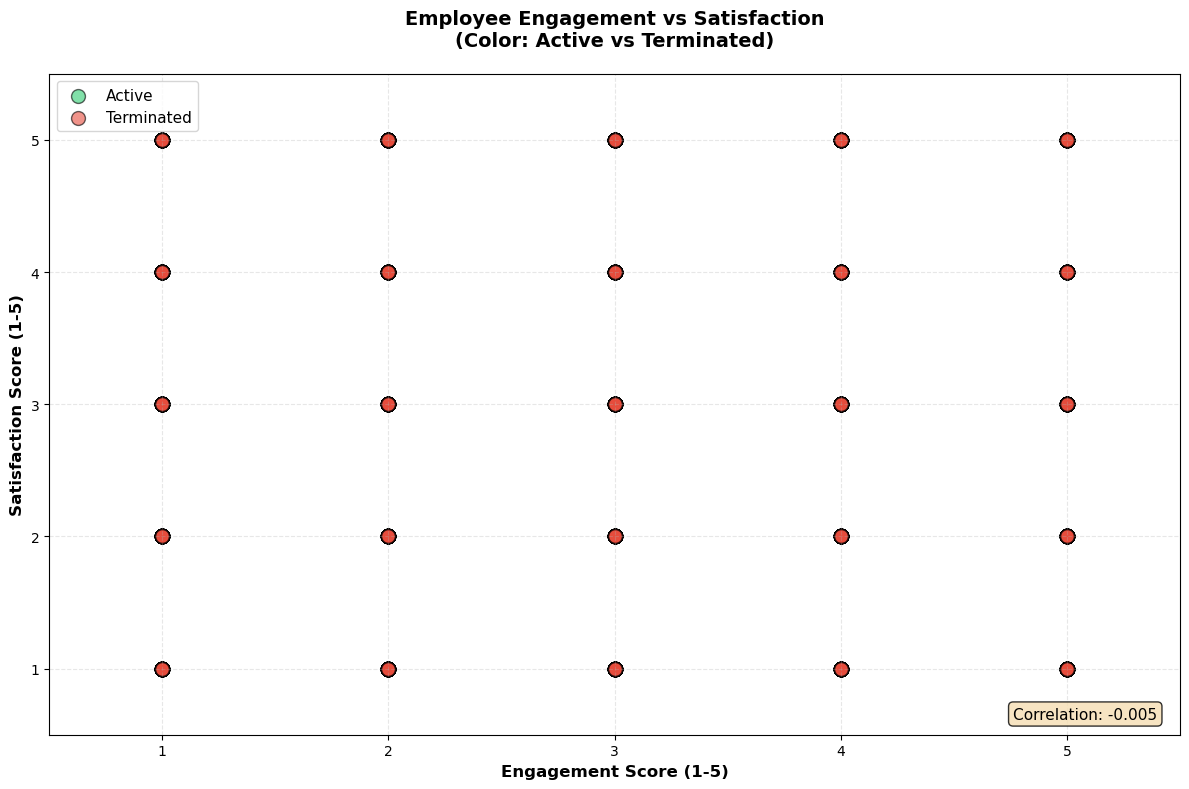

In [34]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Separate by termination status
active = df[df['ExitDate'].isna()]
terminated = df[df['ExitDate'].notna()]

# Scatter plot - Active employees (green)
ax.scatter(active['Engagement Score'], active['Satisfaction Score'],
          s=100, alpha=0.6, c='#2ECC71', label='Active', edgecolors='black')

# Scatter plot - Terminated employees (red)
ax.scatter(terminated['Engagement Score'], terminated['Satisfaction Score'],
          s=100, alpha=0.6, c='#E74C3C', label='Terminated', edgecolors='black')

# Labels and title
ax.set_xlabel('Engagement Score (1-5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Satisfaction Score (1-5)', fontsize=12, fontweight='bold')
ax.set_title('Employee Engagement vs Satisfaction\n(Color: Active vs Terminated)', 
            fontsize=14, fontweight='bold', pad=20)

# Grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)

# Legend
ax.legend(fontsize=11, loc='upper left')

# Add correlation info
corr = df['Engagement Score'].corr(df['Satisfaction Score'])
ax.text(0.98, 0.02, f'Correlation: {corr:.3f}', transform=ax.transAxes,
       fontsize=11, verticalalignment='bottom', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('engagement_vs_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

### Employee Status & Termination Analysis

This visualization provides insights into the current workforce composition and termination patterns within the organization.

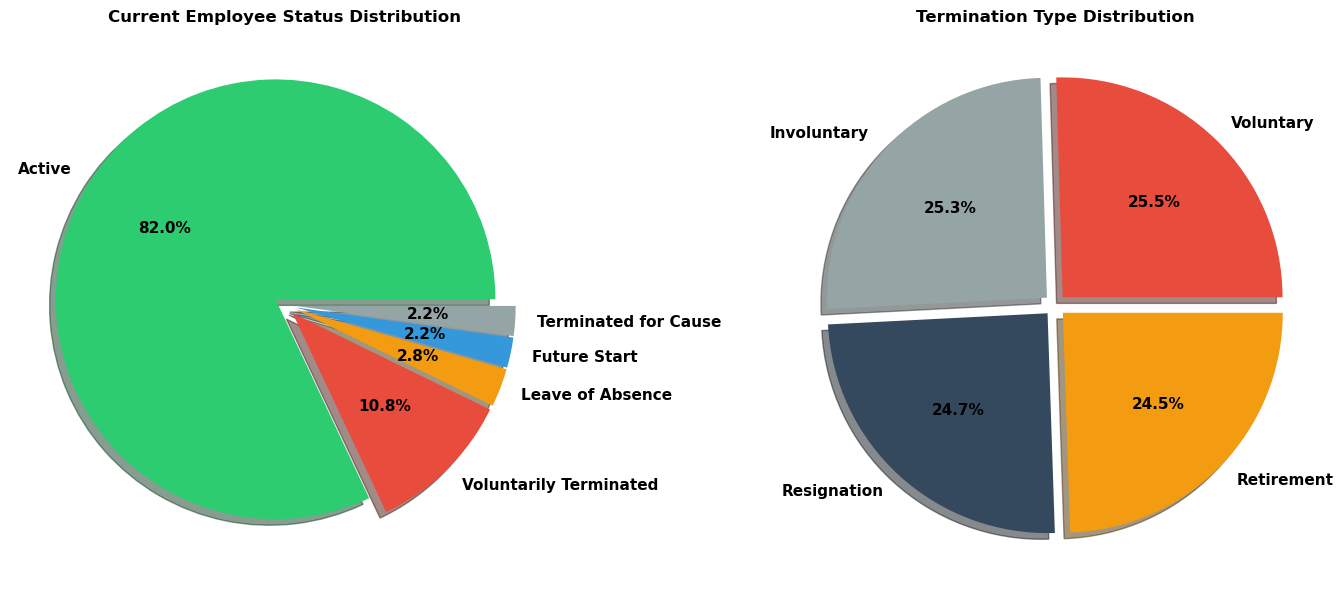

In [36]:
# Calculate distributions
status_dist = df['EmployeeStatus'].value_counts()
terminated_df = df[df['ExitDate'].notna()]
termination_dist = terminated_df['TerminationType'].value_counts()

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# FIXED: Dynamic colors and explode
n_status = len(status_dist)
colors1 = ['#2ECC71', '#E74C3C', '#F39C12', '#3498DB', '#95A5A6'][:n_status]
explode1 = [0.05] * n_status

ax1.pie(status_dist, 
        labels=status_dist.index, 
        autopct='%1.1f%%',
        colors=colors1, 
        explode=explode1,  # ✅ FIXED
        shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Current Employee Status Distribution', fontsize=12, fontweight='bold')

# FIXED: Dynamic for termination types
n_term = len(termination_dist)
colors2 = ['#E74C3C', '#95A5A6', '#34495E', '#F39C12', '#2ECC71'][:n_term]
explode2 = [0.05] * n_term

ax2.pie(termination_dist, 
        labels=termination_dist.index, 
        autopct='%1.1f%%',
        colors=colors2, 
        explode=explode2,  # ✅ FIXED
        shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Termination Type Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('employee_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The analysis includes two pie charts:

1. Employee Status Distribution:
Shows the proportion of employees by current status (e.g., Active, Terminated, Leave).
2. Termination Type Distribution:
Displays the breakdown of termination reasons (only for employees who have exited).

### Employee Performance by Department

This analysis explores how employee performance ratings vary across departments, helping identify patterns, inconsistencies, and potential areas for improvement.

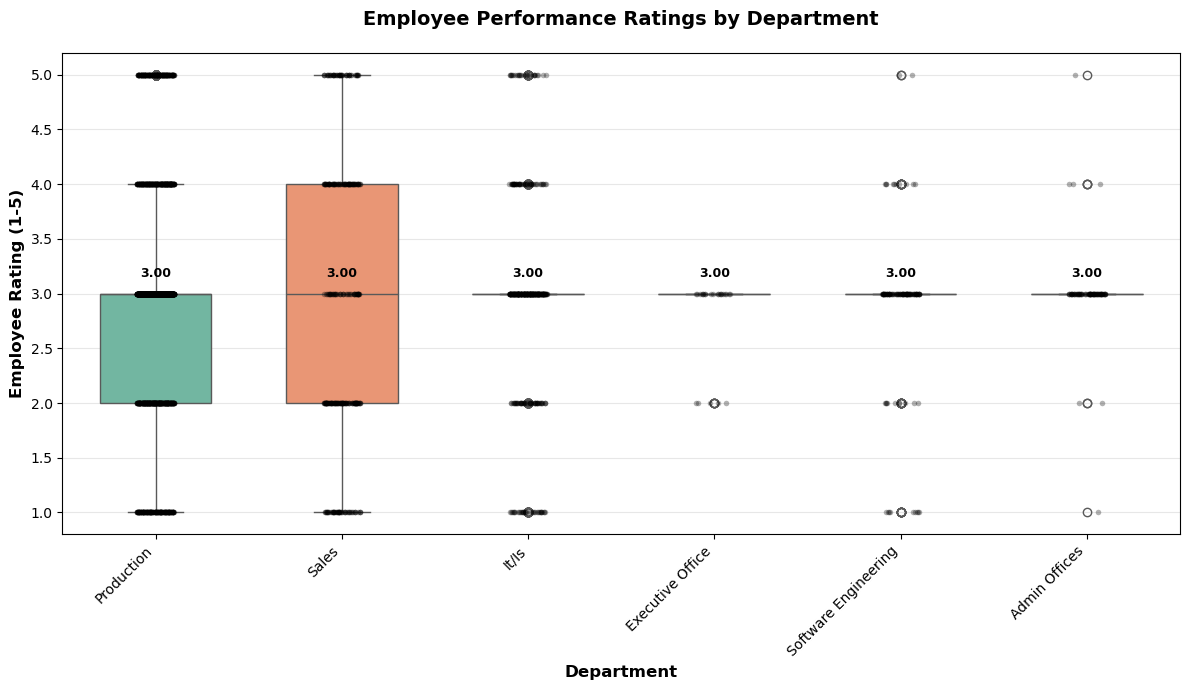

In [37]:
# Filter to numeric ratings only
df['Current Employee Rating'] = pd.to_numeric(df['Current Employee Rating'], errors='coerce')

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create box plot
sns.boxplot(data=df, x='DepartmentType', y='Current Employee Rating',
           palette='Set2', ax=ax, width=0.6)

# Overlay individual points
sns.stripplot(data=df, x='DepartmentType', y='Current Employee Rating',
             color='black', alpha=0.3, size=4, ax=ax)

# Customize
ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Employee Rating (1-5)', fontsize=12, fontweight='bold')
ax.set_title('Employee Performance Ratings by Department', fontsize=14, fontweight='bold', pad=20)

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Grid
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Add median values as text
medians = df.groupby('DepartmentType')['Current Employee Rating'].median()
for i, (dept, median) in enumerate(medians.items()):
    ax.text(i, median + 0.15, f'{median:.2f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('performance_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

The visualization combines:
1. Box Plot → Shows distribution (median, quartiles, spread)
2. Strip Plot Overlay → Displays individual employee ratings

This hybrid approach gives both statistical summary + raw data visibility.

### HR Metrics Heatmap by Department

This visualization provides a high-level comparison of key HR metrics across departments using a color-coded heatmap. It helps quickly identify strong vs weak areas in the organization.

Overview: The heatmap combines multiple metrics into a single view
1. Performance Rating
2. Engagement Score
3. Satisfaction Score
4. Work-Life Balance
5. Tenure (Years)

Each value is:
Normalized (0–1) → for color scaling and Annotated with actual values → for precise interpretation

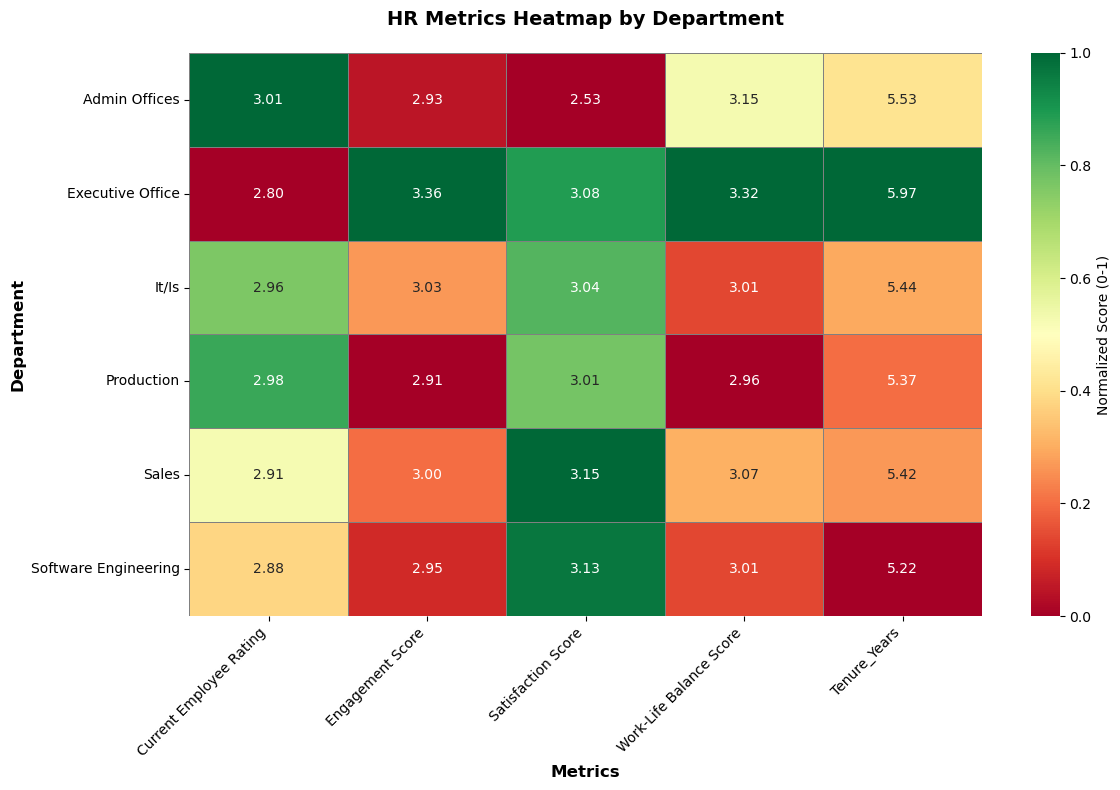

In [38]:
# Select top 10 departments
top_depts = df['DepartmentType'].value_counts().head(10).index
dept_data = df[df['DepartmentType'].isin(top_depts)].copy()

# Calculate metrics by department
metrics_by_dept = dept_data.groupby('DepartmentType').agg({
    'Current Employee Rating': 'mean',
    'Engagement Score': 'mean',
    'Satisfaction Score': 'mean',
    'Work-Life Balance Score': 'mean',
    'Tenure_Years': 'mean'
}).round(2)

# Normalize for heatmap (0-1 scale)
metrics_normalized = (metrics_by_dept - metrics_by_dept.min()) / (metrics_by_dept.max() - metrics_by_dept.min())

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(metrics_normalized, annot=metrics_by_dept, fmt='.2f',
           cmap='RdYlGn', cbar_kws={'label': 'Normalized Score (0-1)'},
           linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title('HR Metrics Heatmap by Department', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Department', fontsize=12, fontweight='bold')

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('hr_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Why This Is Powerful
Instead of looking at metrics individually, this heatmap lets you:

1. See patterns instantly
2. Compare departments side-by-side
3. Make data-driven HR decisions faster

### Employee Turnover Trend Analysis
This visualization tracks employee terminations over time, helping identify patterns, spikes, and long-term attrition trends.

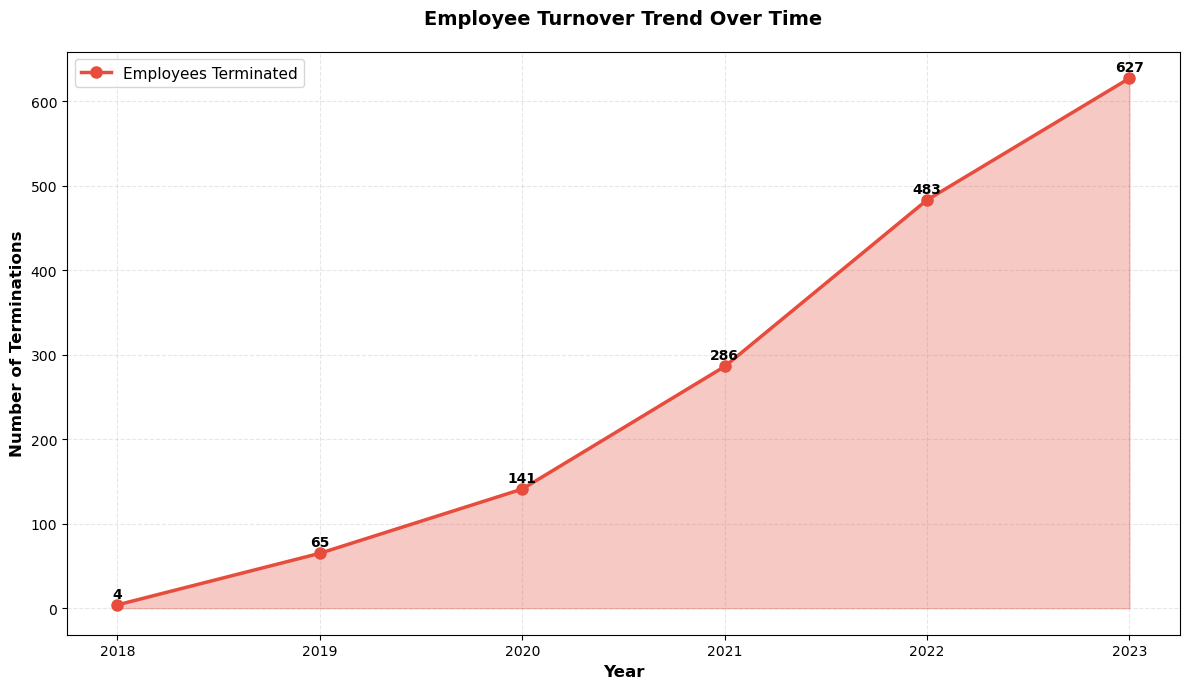

In [39]:
# Extract year from exit date
df['ExitDate'] = pd.to_datetime(df['ExitDate'], errors='coerce')
df['Exit_Year'] = df['ExitDate'].dt.year

# Calculate monthly/yearly turnover
turnover_by_year = df[df['ExitDate'].notna()].groupby('Exit_Year').size()

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot line
ax.plot(turnover_by_year.index, turnover_by_year.values, 
       marker='o', linewidth=2.5, markersize=8, color='#E74C3C', label='Employees Terminated')

# Fill area under line
ax.fill_between(turnover_by_year.index, turnover_by_year.values, alpha=0.3, color='#E74C3C')

# Customize
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Terminations', fontsize=12, fontweight='bold')
ax.set_title('Employee Turnover Trend Over Time', fontsize=14, fontweight='bold', pad=20)

# Grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels on points
for x, y in zip(turnover_by_year.index, turnover_by_year.values):
    ax.text(x, y + 5, str(int(y)), ha='center', va='bottom', fontweight='bold')

# Legend
ax.legend(fontsize=11, loc='upper left')

# Set integer x-axis
ax.set_xticks(turnover_by_year.index)

plt.tight_layout()
plt.savefig('turnover_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### Why This Matters

Understanding turnover trends helps organizations
1. Reduce unexpected employee loss
2. Improve retention strategies
3. Align HR policies with workforce stability

### Termination Analysis by Department

This visualization explores how employee terminations vary across departments, broken down by termination type. It helps HR teams understand where and why employees are leaving.

Overview:The chart uses a stacked bar plot to show

1. Departments on the x-axis
2. Number of terminations on the y-axis
3. Different colors representing termination types

This allows easy comparison of both volume and composition of exits.

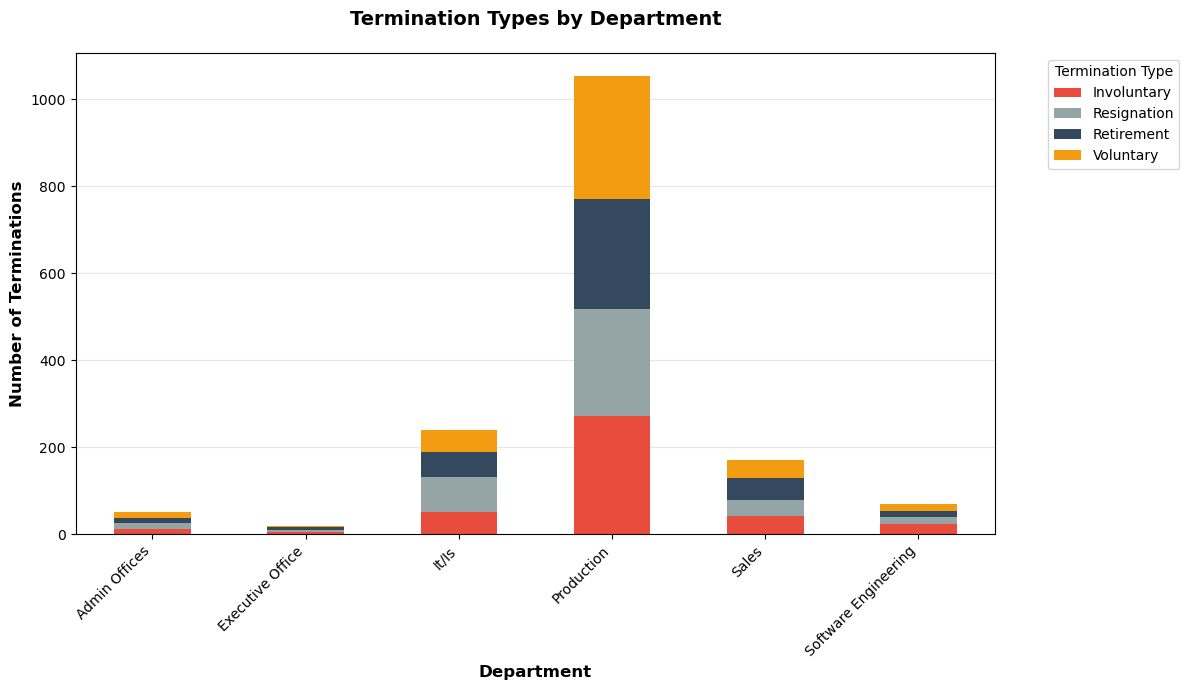

In [40]:
# Create cross-tabulation
termination_by_dept = pd.crosstab(df['DepartmentType'], df['TerminationType'])

# Only plot terminated employees
terminated_df = df[df['ExitDate'].notna()]
termination_by_dept = pd.crosstab(terminated_df['DepartmentType'], 
                                   terminated_df['TerminationType'])

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))

termination_by_dept.plot(kind='bar', stacked=True, ax=ax,
                         color=['#E74C3C', '#95A5A6', '#34495E', '#F39C12'])

# Customize
ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Terminations', fontsize=12, fontweight='bold')
ax.set_title('Termination Types by Department', fontsize=14, fontweight='bold', pad=20)

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Legend
ax.legend(title='Termination Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Grid
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('termination_by_department.png', dpi=300, bbox_inches='tight')
plt.show()



### Training Program Effectiveness Analysis

This visualization evaluates the success rates of training programs, helping identify which programs deliver the best outcomes for employees.

Each program is ranked and visualized using a horizontal bar chart with a performance-based.

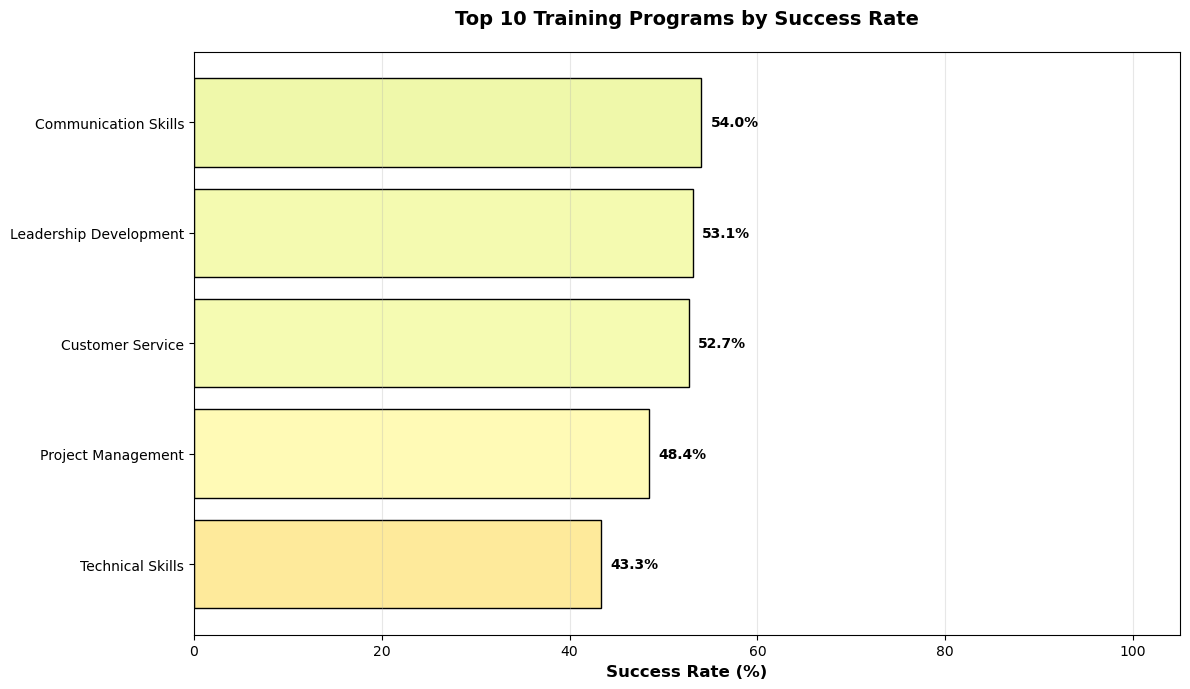

In [41]:
# Training success by program
training_data = df[df['Training Program Name'].notna()].copy()

success_rates = training_data.groupby('Training Program Name').apply(
    lambda x: (x['Training Outcome'].isin(['Passed', 'Completed']).sum() / len(x) * 100)
).sort_values(ascending=True).tail(10)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Horizontal bar with color gradient
colors = plt.cm.RdYlGn(success_rates.values / 100)
bars = ax.barh(range(len(success_rates)), success_rates.values, color=colors, edgecolor='black')

# Customize
ax.set_yticks(range(len(success_rates)))
ax.set_yticklabels(success_rates.index, fontsize=10)
ax.set_xlabel('Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Training Programs by Success Rate', fontsize=14, fontweight='bold', pad=20)

# Value labels
for i, (bar, val) in enumerate(zip(bars, success_rates.values)):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, 
           f'{val:.1f}%', va='center', fontweight='bold')

# Grid
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('training_effectiveness.png', dpi=300, bbox_inches='tight')
plt.show()

### Employee Status Visualization (HR Color Scheme)

This visualization highlights the distribution of employee statuses using a consistent and intuitive HR-focused color scheme.

Overview:

The chart displays the number of employees by status (e.g., Active, Future Start)

Why This Matters:
1. Improves readability & interpretation
2. Creates visual consistency across reports
3. Helps stakeholders quickly identify key patterns

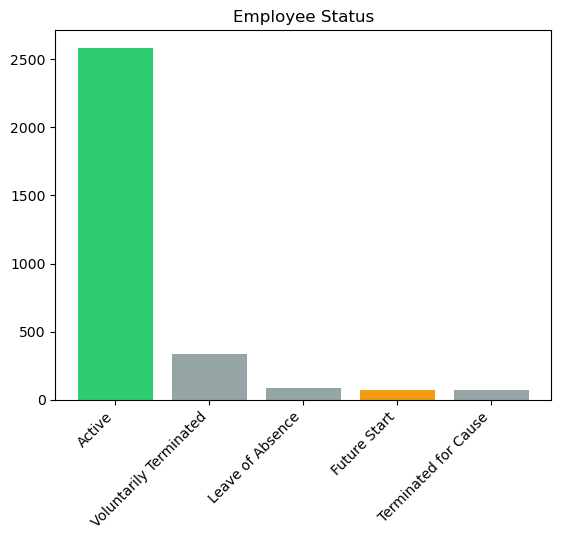

In [44]:
# Color scheme for HR dashboards
# Define colors
hr_colors = {'active': '#2ECC71', 'terminated': '#E74C3C', 'good': '#3498DB'}

# GET DATA (this is what you were missing!)
status_data = df['EmployeeStatus'].value_counts()

# Map colors
color_map = {'Active': hr_colors['active'], 'Future Start': '#F39C12'}
colors = [color_map.get(s, '#95A5A6') for s in status_data.index]

# Rotate labels
plt.xticks(rotation=45, ha='right')

# PLOT (now it works!)
plt.bar(status_data.index, status_data.values, color=colors)
plt.title('Employee Status')
plt.show()

### HR At-Risk Employee Dashboard

This dashboard identifies employees at risk of attrition using engagement, satisfaction, and performance data. It helps HR teams take proactive action before employees leave.

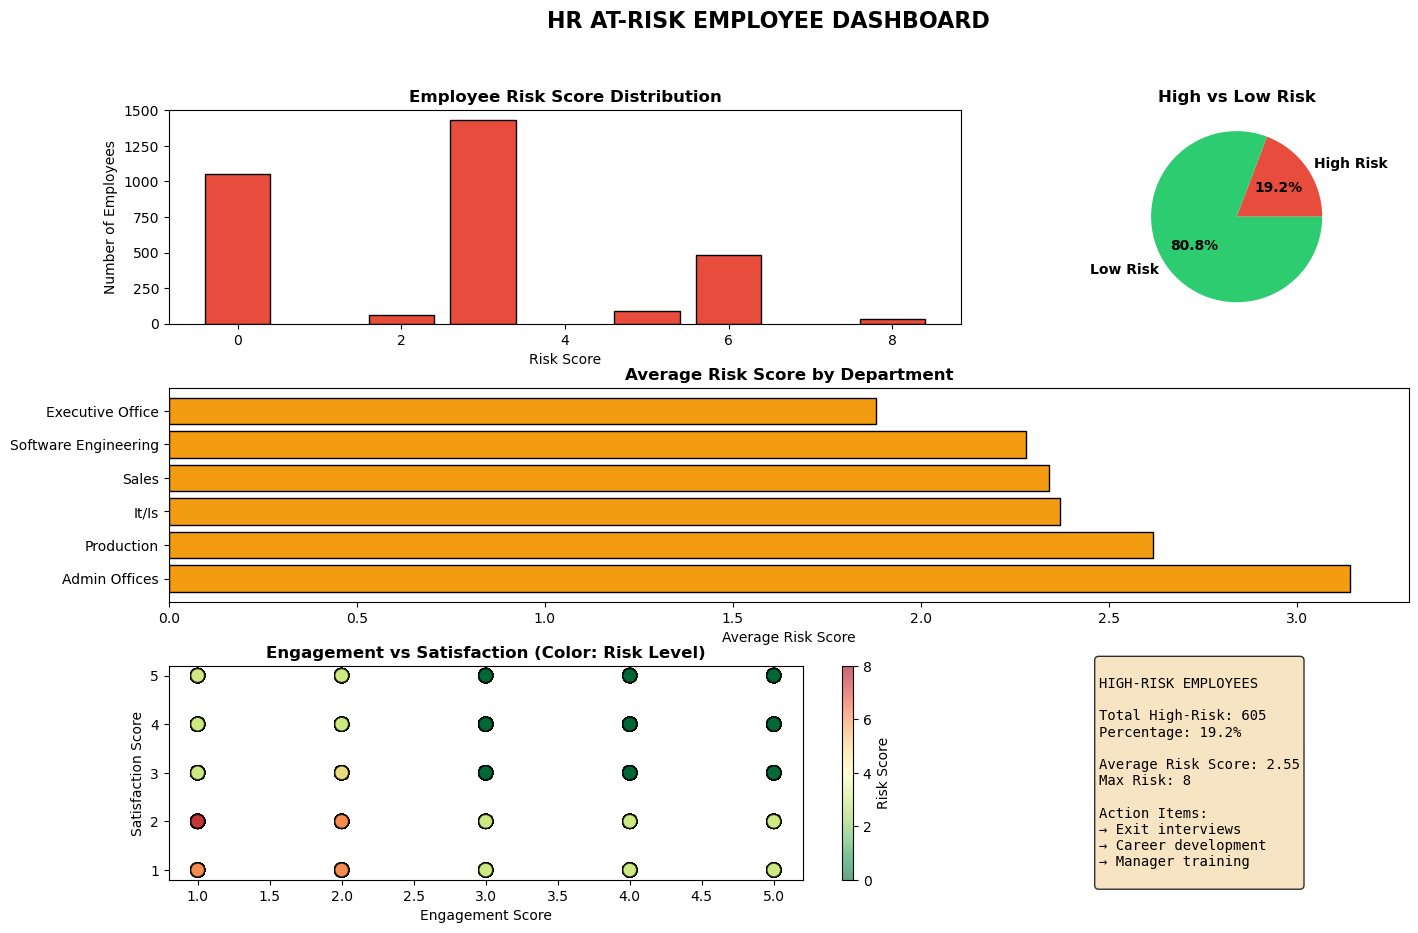

In [45]:
# Create risk score
df['Risk_Score'] = 0
df.loc[df['Engagement Score'] <= 2, 'Risk_Score'] += 3
df.loc[df['Satisfaction Score'] <= 2, 'Risk_Score'] += 3
df.loc[df['Performance Score'] == 'Needs Improvement', 'Risk_Score'] += 2

# Create comprehensive dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Chart 1: Risk score distribution
ax1 = fig.add_subplot(gs[0, :2])
risk_dist = df['Risk_Score'].value_counts().sort_index()
ax1.bar(risk_dist.index, risk_dist.values, color='#E74C3C', edgecolor='black')
ax1.set_title('Employee Risk Score Distribution', fontweight='bold')
ax1.set_xlabel('Risk Score')
ax1.set_ylabel('Number of Employees')

# Chart 2: High-risk count
ax2 = fig.add_subplot(gs[0, 2])
high_risk = len(df[df['Risk_Score'] >= 5])
low_risk = len(df[df['Risk_Score'] < 5])
ax2.pie([high_risk, low_risk], labels=['High Risk', 'Low Risk'], autopct='%1.1f%%',
        colors=['#E74C3C', '#2ECC71'], textprops={'fontweight': 'bold'})
ax2.set_title('High vs Low Risk', fontweight='bold')

# Chart 3: Risk by department
ax3 = fig.add_subplot(gs[1, :])
risk_by_dept = df.groupby('DepartmentType')['Risk_Score'].mean().sort_values(ascending=False)
ax3.barh(risk_by_dept.index, risk_by_dept.values, color='#F39C12', edgecolor='black')
ax3.set_title('Average Risk Score by Department', fontweight='bold')
ax3.set_xlabel('Average Risk Score')

# Chart 4: Engagement vs Satisfaction (colored by risk)
ax4 = fig.add_subplot(gs[2, :2])
scatter = ax4.scatter(df['Engagement Score'], df['Satisfaction Score'],
                     c=df['Risk_Score'], s=100, cmap='RdYlGn_r', alpha=0.6, edgecolors='black')
ax4.set_xlabel('Engagement Score')
ax4.set_ylabel('Satisfaction Score')
ax4.set_title('Engagement vs Satisfaction (Color: Risk Level)', fontweight='bold')
plt.colorbar(scatter, ax=ax4, label='Risk Score')

# Chart 5: Stats box
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
stats_text = f"""
HIGH-RISK EMPLOYEES

Total High-Risk: {high_risk}
Percentage: {high_risk/len(df)*100:.1f}%

Average Risk Score: {df['Risk_Score'].mean():.2f}
Max Risk: {df['Risk_Score'].max():.0f}

Action Items:
→ Exit interviews
→ Career development
→ Manager training
"""
ax5.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), family='monospace')

plt.suptitle('HR AT-RISK EMPLOYEE DASHBOARD', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('hr_at_risk_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

The dashboard combines multiple visualizations to provide a 360° view of employee risk:

1. Risk score distribution
2. High vs low-risk segmentation
3. Average Risk by department
4. Engagement vs satisfaction (risk-colored)
5. Summary insights panel